# Breakout 아타리 게임 학습 (DQN)
- 프로그램 7-5 참고
- `ALE/Breakout-v5` 환경 사용
- 학습된 모델은 `fbreakout.keras`로 저장
- 전체 흐름: 게임 화면(영상) → 전처리(84×84 흑백) → CNN 신경망 → Q값 → 행동 선택 → 리플레이 메모리 → 학습

In [1]:
import gymnasium as gym
import numpy as np
import random

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten
from tensorflow.keras.optimizers import Adam
# /Users/ksydata/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: 
# NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, 
# currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020warnings.warn(

# pip install tensorflow==2.13.1
# pip install "keras>=2.13.1,<2.14"
# ModuleNotFoundError: No module named 'tensorflow.keras'

import ale_py
import cv2 as cv

import matplotlib.pyplot as plt
from collections import deque
import time

/Users/ksydata/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
import tensorflow as tf, time

if tf.config.list_physical_devices("GPU"):
    with tf.device("/GPU:0"):
        a = tf.random.normal((2000, 2000))
        t0 = time.time(); _ = tf.matmul(a, a); tf.print("matmul executed"); tf.keras.backend.clear_session()
        t1 = time.time()
        print("Elapsed (GPU):", t1-t0)
else:
    print("No GPU found")
# python3 -m pip show tensorflow-metal 2>&1 | grep -E "Name|Version|not found" && system_profiler SPHardwareDataType | grep -E "Chip|Processor"

matmul executed
Elapsed (GPU): 0.011948823928833008


2026-06-13 15:21:23.656734: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-06-13 15:21:23.656868: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-13 15:21:23.656875: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-06-13 15:21:23.657148: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-13 15:21:23.657411: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


---

In [3]:
gamma = 0.99 # 할인율: 미래 보상을 현재 가치로 환산 (1에 가까울수록 미래 중시)
eps = 1.0 # 탐험률(ε): 처음엔 랜덤 행동, 점점 학습된 행동으로 전환
eps_decay = 0.99999 # 매 스텝마다 ε에 곱하는 감소율
eps_min = 0.01 # ε의 최솟값 (최소 1%는 계속 랜덤 행동)
replay_memory_size = 20000 # 리플레이 메모리 최대 크기 (오래된 경험은 자동 삭제)
batch_size = 32 # 한 번 학습 시 메모리에서 꺼내는 샘플 수
copy_interval = 1000  # 행위 신경망 가중치를 목표 신경망에 복사하는 주기(스텝)
n_match = 500 # 총 학습할 경기 수
consecutive = 4 # 연속 4장의 프레임으로 1개의 상태 표현 (움직임 방향 파악)
rows = 84 # 신경망 입력 영상 높이 (84×84로 축소)
cols = 84 # 신경망 입력 영상 너비
actions = [0,1,2,3]   # 행동: 0(위치 유지, 정지), 1(FIRE, 공 발사), 2(오른쪽 이동), 3(왼쪽 이동)

In [4]:
greedy_select = lambda x: np.random.choice(
    np.argwhere( 
        x == np.max(x)).flatten()
)
# Q값이 동률일 때 무작위로 하나를 선택하는 탐욕 함수

In [5]:
def deep_network(): 
    """CNN 기반 Q-Network 신경망 생성하는 메서드
    
    - 입력: (84, 84, 4) — 4장의 연속 흑백 프레임
    - 출력: 각 행동에 대한 Q값 (len(actions)개)
    """

    cnn = Sequential()
    cnn.add(
        Conv2D(32, (5,5), 
               activation = "relu",
               strides=2,
               input_shape = (rows, cols, consecutive)) )
    # 특징 추출 (stride = 2로 크기 절반)

    cnn.add(Conv2D(64, (3,3), 
                   activation = "relu", 
                   strides = 2) )
    # 더 깊은 특징 추출 (stride = 2로 크기 절반)
    cnn.add(Conv2D(64, (3,3), 
                   activation = "relu", strides = 1))
    # 더 깊은 특징 추출 (stride = 1로 크기 유지)
    cnn.add(Flatten())
    # CNN → 완전 연결층으로 전환(2D → 1D 벡터로 펼치기)

    cnn.add(Dense(512, 
                  activation = "relu"))
    # 완전 연결층: 512개의 뉴런, ReLU 활성화
    cnn.add(Dense(len(actions),
                  activation = "linear"))
    # 출력층: 각 행동에 대한 Q값 출력 (선형 활성화)
    cnn.compile(loss = "MSE",
                optimizer = Adam(learning_rate = 0.00005))
    # 손실 함수: 평균 제곱 오차
    # 최적화 알고리즘: Adam (학습률 0.005%)
    return cnn
    # 신경망 모델 반환

In [6]:
def preprocess(img):
    """게임 화면 영상 전처리 (210×160×3 컬러 → 84×84×1 명암)"""
    crop = cv.cvtColor(img[30:-10, 5:-5, :],
                       cv.COLOR_BGR2GRAY)
    # img[30:-10, 5:-5] : 상단 점수판·하단 여백·좌우 경계 제거(crop)
    # 흑백 변환 (컬러 → 명암)
    return cv.resize(crop,dsize=(rows, cols)).reshape(rows, cols, 1)
    # 84×84로 축소하고 명암으로 변환하여 1채널로 만듦 (CNN 입력 형태)

In [7]:
def model_learning(): 
    """리플레이 메모리에서 무작위 미니배치를 꺼내 신경망 학습 (Experience Replay), DQN 학습"""
    mini_batch = random.sample(range(len(R)),batch_size)
    s = np.asarray([ R[mini_batch[i]][0] for i in range(batch_size) ])
    # 현재 상태
    a = np.asarray([ R[mini_batch[i]][1] for i in range(batch_size) ])
    # 선택 행동
    r = np.asarray([ R[mini_batch[i]][2] for i in range(batch_size) ])
    # 받은 보상
    s1 = np.asarray([ R[mini_batch[i]][3] for i in range(batch_size) ])
    # 다음 상태
    terminated = np.asarray([ R[mini_batch[i]][4] for i in range(batch_size) ])
    # 종료 여부

    X = s
    Y = np.array(model_behavior(s))
    # 행위 신경망의 현재 Q값 예측, 
    y1_ = np.array(model_target(s1))
    # 목표 신경망의 다음 상태 Q값 예측

    for i in range(batch_size):
        if terminated[i]:
            Y[i,a[i]] = r[i]
            # 종료 상태: Q = r (미래 보상 없음)
        else:
            Y[i,a[i]] = r[i] + gamma*np.max(y1_[i])
            # 벨만 방정식: Q = r + γ * max Q(s')

    model_behavior.fit(X,Y,batch_size=batch_size,epochs=1,verbose=0)
    # 행위 신경망만 학습 (목표 신경망은 copy_interval마다 갱신)

---

In [8]:
gym.register_envs(ale_py)
env = gym.make('ALE/Breakout-v5', render_mode='rgb_array')
# ALE/Breakout-v5 환경 등록 (OpenAI Gym에서 Atari Breakout 게임 환경 사용)

model_target   = deep_network()  
# 목표 신경망 생성: 안정적인 Q 타깃 계산용 (copy_interval마다 갱신)
model_behavior = deep_network() 
# 행위 신경망: 실제로 학습되는 신경망 (데이터 생성용)

R = deque(maxlen = replay_memory_size)  
# 리플레이 메모리 초기화
n_update = 0
# 누적 프레임 수
scores = []
# 경기(match) 점수 기록
start_time_total = time.time()

for i in range(n_match):  
    # 경기 반복
    start = time.time()
    obs, info = env.reset()
    obs, _, _, _, _ = env.step(1)  
    # FIRE: 공 발사하여 게임 시작
    # Breakout은 Atari Pong과 달리 FIRE(1)를 눌러야 공이 발사되어 게임 시작

    imem = deque(maxlen = consecutive)  
    # 4장의 연속 영상으로 상태 표현
    for j in range(consecutive): 
        imem.append(preprocess(obs))
    # ?
    s = np.transpose(np.squeeze(np.asarray(imem)),(1,2,0))
    # CNN 입력 형태로 변환 
    # (4,84,84) → (84,84,4)

    score = 0
    while True:
        # ε-탐욕 정책: ε 확률로 랜덤, (1-ε) 확률로 Q값 최대 행동 선택
        if(np.random.random()<eps):
        # 탐험(exploration): 랜덤 행동
            a = np.random.choice(len(actions))  # 랜덤 선택
        else:
        # 활용(exploitation): Q값 최대 행동
            y_ = model_behavior(s.reshape(1,rows,cols,consecutive))[0]
            a  = greedy_select(y_)              # 탐욕 선택

        obs1,r,terminated,truncated,info = env.step(actions[a])
        imem.append(preprocess(obs1))
        s1 = np.transpose(np.squeeze(np.asarray(imem)),(1,2,0))
        # 다음 상태 CNN 입력 형태로 변환
        R.append((s,a,r,s1,terminated))
        # 경험을 메모리에 저장        
        eps = max(eps_min, eps*eps_decay)  
        # 엡실론을 조금씩 줄임, ε 감소 (점점 덜 탐험)

        if len(R) > batch_size * 3 and n_update % 4 == 0:
        # 메모리가 충분히 쌓이면 4스텝마다 1번 학습 
            model_learning()

        n_update += 1
        if n_update % copy_interval == 0:
        # copy_interval마다 행위 신경망 가중치 → 목표 신경망에 복사 (학습 안정화)            
            model_target.set_weights(model_behavior.get_weights())

        s = s1

        if r!=0:  
        # 게임 종료
            score += r
        if terminated or truncated:  
        # 경기 종료
            scores.append(score)
            break

    print(i+1,"번째 경기 점수 = ", 
          scores[-1],"(", int(time.time()-start),"초) eps=", np.round(eps, 8))

print("학습에 걸린 총 시간 = ", int(time.time()-start_time_total),'초')
model_target.save("fbreakout.keras")  
# 학습 완료된 신경망 모델은 `fbreakout.keras`로 저장 → breakout_test.ipynb에서 사용
env.close()

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
2026-06-13 15:21:44.507210: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1 번째 경기 점수 =  0 ( 6 초) eps= 0.99855104
2 번째 경기 점수 =  0 ( 2 초) eps= 0.99725376
3 번째 경기 점수 =  2.0 ( 5 초) eps= 0.99493286
4 번째 경기 점수 =  2.0 ( 3 초) eps= 0.99287546
5 번째 경기 점수 =  0 ( 2 초) eps= 0.99150623
6 번째 경기 점수 =  3.0 ( 5 초) eps= 0.98860536
7 번째 경기 점수 =  1.0 ( 3 초) eps= 0.98677812
8 번째 경기 점수 =  1.0 ( 2 초) eps= 0.9852892
9 번째 경기 점수 =  0 ( 2 초) eps= 0.98396979
10 번째 경기 점수 =  1.0 ( 3 초) eps= 0.98220023
11 번째 경기 점수 =  0 ( 2 초) eps= 0.98094381
12 번째 경기 점수 =  0 ( 2 초) eps= 0.97950288
13 번째 경기 점수 =  1.0 ( 3 초) eps= 0.97788802
14 번째 경기 점수 =  0 ( 2 초) eps= 0.97661759
15 번째 경기 점수 =  0 ( 2 초) eps= 0.97540733
16 번째 경기 점수 =  2.0 ( 3 초) eps= 0.97340005
17 번째 경기 점수 =  1.0 ( 3 초) eps= 0.97163006
18 번째 경기 점수 =  1.0 ( 3 초) eps= 0.96999908
19 번째 경기 점수 =  2.0 ( 4 초) eps= 0.96782871
20 번째 경기 점수 =  1.0 ( 3 초) eps= 0.96613648
21 번째 경기 점수 =  2.0 ( 3 초) eps= 0.96416756
22 번째 경기 점수 =  1.0 ( 3 초) eps= 0.96252986
23 번째 경기 점수 =  0 ( 2 초) eps= 0.96134667
24 번째 경기 점수 =  0 ( 2 초) eps= 0.96011693
25 번째 경기 점수 =  2.0 ( 3

---

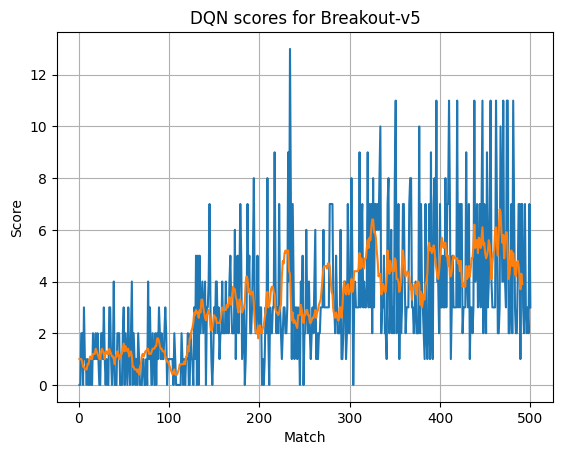

In [9]:
# 경기별 점수 시각화
plt.plot(
    range(1, len(scores) + 1), 
    scores)
smooth = np.convolve(
    scores, 
    10*[0.1], 
    mode = "valid")
plt.plot(
    range(1, len(smooth) + 1),
    smooth)
plt.title("DQN scores for Breakout-v5")
plt.ylabel("Score")
plt.xlabel("Match")
plt.grid()
plt.show()

### OpenAI Gym에서 Atari ALE/Breakout-v5 게임환경에서 경기 반복 수행 과정
```
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]

1 번째 경기 점수 =  0 ( 6 초) eps= 0.99855104
2 번째 경기 점수 =  0 ( 2 초) eps= 0.99725376
3 번째 경기 점수 =  2.0 ( 5 초) eps= 0.99493286
4 번째 경기 점수 =  2.0 ( 3 초) eps= 0.99287546
5 번째 경기 점수 =  0 ( 2 초) eps= 0.99150623
6 번째 경기 점수 =  3.0 ( 5 초) eps= 0.98860536
7 번째 경기 점수 =  1.0 ( 3 초) eps= 0.98677812
8 번째 경기 점수 =  1.0 ( 2 초) eps= 0.9852892
9 번째 경기 점수 =  0 ( 2 초) eps= 0.98396979
10 번째 경기 점수 =  1.0 ( 3 초) eps= 0.98220023
11 번째 경기 점수 =  0 ( 2 초) eps= 0.98094381
12 번째 경기 점수 =  0 ( 2 초) eps= 0.97950288
13 번째 경기 점수 =  1.0 ( 3 초) eps= 0.97788802
14 번째 경기 점수 =  0 ( 2 초) eps= 0.97661759
15 번째 경기 점수 =  0 ( 2 초) eps= 0.97540733
16 번째 경기 점수 =  2.0 ( 3 초) eps= 0.97340005
17 번째 경기 점수 =  1.0 ( 3 초) eps= 0.97163006
18 번째 경기 점수 =  1.0 ( 3 초) eps= 0.96999908
19 번째 경기 점수 =  2.0 ( 4 초) eps= 0.96782871
20 번째 경기 점수 =  1.0 ( 3 초) eps= 0.96613648
21 번째 경기 점수 =  2.0 ( 3 초) eps= 0.96416756
22 번째 경기 점수 =  1.0 ( 3 초) eps= 0.96252986
23 번째 경기 점수 =  0 ( 2 초) eps= 0.96134667
24 번째 경기 점수 =  0 ( 2 초) eps= 0.96011693
25 번째 경기 점수 =  2.0 ( 3 초) eps= 0.95809321
26 번째 경기 점수 =  2.0 ( 3 초) eps= 0.9561598
27 번째 경기 점수 =  1.0 ( 3 초) eps= 0.95454525
28 번째 경기 점수 =  3.0 ( 4 초) eps= 0.95221898
29 번째 경기 점수 =  1.0 ( 3 초) eps= 0.95071566
30 번째 경기 점수 =  0 ( 2 초) eps= 0.949528
31 번째 경기 점수 =  1.0 ( 3 초) eps= 0.94790569
32 번째 경기 점수 =  0 ( 2 초) eps= 0.94674994
33 번째 경기 점수 =  0 ( 3 초) eps= 0.94542541
34 번째 경기 점수 =  3.0 ( 3 초) eps= 0.94338549
35 번째 경기 점수 =  3.0 ( 4 초) eps= 0.9408794
36 번째 경기 점수 =  1.0 ( 3 초) eps= 0.93920612
37 번째 경기 점수 =  0 ( 2 초) eps= 0.93779836
38 번째 경기 점수 =  1.0 ( 2 초) eps= 0.93625226
39 번째 경기 점수 =  4.0 ( 4 초) eps= 0.93379314
40 번째 경기 점수 =  0 ( 2 초) eps= 0.93253336
41 번째 경기 점수 =  0 ( 2 초) eps= 0.93133117
42 번째 경기 점수 =  0 ( 2 초) eps= 0.93011191
43 번째 경기 점수 =  2.0 ( 3 초) eps= 0.92828139
44 번째 경기 점수 =  2.0 ( 3 초) eps= 0.92636182
45 번째 경기 점수 =  2.0 ( 4 초) eps= 0.92429833
46 번째 경기 점수 =  0 ( 2 초) eps= 0.92304213
47 번째 경기 점수 =  0 ( 2 초) eps= 0.9219167
48 번째 경기 점수 =  0 ( 2 초) eps= 0.92067295
49 번째 경기 점수 =  2.0 ( 3 초) eps= 0.91884262
50 번째 경기 점수 =  3.0 ( 4 초) eps= 0.91650254
51 번째 경기 점수 =  0 ( 2 초) eps= 0.91538509
52 번째 경기 점수 =  2.0 ( 3 초) eps= 0.913547
53 번째 경기 점수 =  1.0 ( 3 초) eps= 0.91189497
54 번째 경기 점수 =  0 ( 2 초) eps= 0.9106192
55 번째 경기 점수 =  3.0 ( 4 초) eps= 0.90849083
56 번째 경기 점수 =  1.0 ( 2 초) eps= 0.90707469
57 번째 경기 점수 =  0 ( 2 초) eps= 0.90589625
58 번째 경기 점수 =  2.0 ( 3 초) eps= 0.90404106
59 번째 경기 점수 =  4.0 ( 5 초) eps= 0.90144115
60 번째 경기 점수 =  0 ( 2 초) eps= 0.900153
61 번째 경기 점수 =  2.0 ( 3 초) eps= 0.89831855
62 번째 경기 점수 =  1.0 ( 2 초) eps= 0.89695414
63 번째 경기 점수 =  0 ( 2 초) eps= 0.89580677
64 번째 경기 점수 =  1.0 ( 2 초) eps= 0.89436567
65 번째 경기 점수 =  0 ( 2 초) eps= 0.89313229
66 번째 경기 점수 =  2.0 ( 4 초) eps= 0.89108935
67 번째 경기 점수 =  1.0 ( 3 초) eps= 0.88966474
68 번째 경기 점수 =  0 ( 2 초) eps= 0.88847338
69 번째 경기 점수 =  0 ( 2 초) eps= 0.88723038
70 번째 경기 점수 =  0 ( 2 초) eps= 0.88599798
71 번째 경기 점수 =  1.0 ( 3 초) eps= 0.88445768
72 번째 경기 점수 =  1.0 ( 3 초) eps= 0.88291122
73 번째 경기 점수 =  0 ( 2 초) eps= 0.88174654
74 번째 경기 점수 =  0 ( 2 초) eps= 0.88057459
75 번째 경기 점수 =  1.0 ( 3 초) eps= 0.8790613
76 번째 경기 점수 =  0 ( 2 초) eps= 0.87787536
77 번째 경기 점수 =  4.0 ( 5 초) eps= 0.87545576
78 번째 경기 점수 =  1.0 ( 3 초) eps= 0.8737328
79 번째 경기 점수 =  3.0 ( 4 초) eps= 0.87155118
80 번째 경기 점수 =  1.0 ( 3 초) eps= 0.8701317
81 번째 경기 점수 =  0 ( 2 초) eps= 0.86893174
82 번째 경기 점수 =  2.0 ( 3 초) eps= 0.86709155
83 번째 경기 점수 =  1.0 ( 3 초) eps= 0.86570531
84 번째 경기 점수 =  0 ( 2 초) eps= 0.8646152
85 번째 경기 점수 =  2.0 ( 4 초) eps= 0.86271513
86 번째 경기 점수 =  0 ( 2 초) eps= 0.86155124
87 번째 경기 점수 =  2.0 ( 4 초) eps= 0.85968369
88 번째 경기 점수 =  1.0 ( 2 초) eps= 0.85836938
89 번째 경기 점수 =  3.0 ( 4 초) eps= 0.85619187
90 번째 경기 점수 =  2.0 ( 3 초) eps= 0.85443847
91 번째 경기 점수 =  1.0 ( 2 초) eps= 0.85311511
92 번째 경기 점수 =  2.0 ( 4 초) eps= 0.85111263
93 번째 경기 점수 =  1.0 ( 3 초) eps= 0.84976043
94 번째 경기 점수 =  1.0 ( 3 초) eps= 0.84816438
95 번째 경기 점수 =  2.0 ( 3 초) eps= 0.84663058
96 번째 경기 점수 =  3.0 ( 4 초) eps= 0.84460954
97 번째 경기 점수 =  2.0 ( 3 초) eps= 0.84297258
98 번째 경기 점수 =  0 ( 2 초) eps= 0.84191109
99 번째 경기 점수 =  1.0 ( 3 초) eps= 0.84053148
100 번째 경기 점수 =  1.0 ( 3 초) eps= 0.83912057
101 번째 경기 점수 =  1.0 ( 3 초) eps= 0.83767852
102 번째 경기 점수 =  1.0 ( 3 초) eps= 0.83636439
103 번째 경기 점수 =  1.0 ( 2 초) eps= 0.83501892
104 번째 경기 점수 =  1.0 ( 3 초) eps= 0.83361725
105 번째 경기 점수 =  0 ( 2 초) eps= 0.83260918
106 번째 경기 점수 =  2.0 ( 4 초) eps= 0.83080437
107 번째 경기 점수 =  1.0 ( 3 초) eps= 0.82937661
108 번째 경기 점수 =  0 ( 2 초) eps= 0.8283074
109 번째 경기 점수 =  0 ( 2 초) eps= 0.82724784
110 번째 경기 점수 =  0 ( 2 초) eps= 0.82620615
111 번째 경기 점수 =  0 ( 2 초) eps= 0.82514928
112 번째 경기 점수 =  0 ( 2 초) eps= 0.82406904
113 번째 경기 점수 =  0 ( 2 초) eps= 0.82282563
114 번째 경기 점수 =  2.0 ( 3 초) eps= 0.82127195
115 번째 경기 점수 =  1.0 ( 3 초) eps= 0.81978678
116 번째 경기 점수 =  0 ( 2 초) eps= 0.81851709
117 번째 경기 점수 =  1.0 ( 3 초) eps= 0.8170941
118 번째 경기 점수 =  0 ( 2 초) eps= 0.81608969
119 번째 경기 점수 =  1.0 ( 3 초) eps= 0.81476054
120 번째 경기 점수 =  1.0 ( 3 초) eps= 0.81334408
121 번째 경기 점수 =  2.0 ( 3 초) eps= 0.81177583
122 번째 경기 점수 =  0 ( 2 초) eps= 0.81068878
123 번째 경기 점수 =  0 ( 2 초) eps= 0.80958699
124 번째 경기 점수 =  2.0 ( 4 초) eps= 0.807824
125 번째 경기 점수 =  1.0 ( 3 초) eps= 0.80652444
126 번째 경기 점수 =  1.0 ( 3 초) eps= 0.80520282
127 번째 경기 점수 =  0 ( 2 초) eps= 0.80413261
128 번째 경기 점수 =  3.0 ( 5 초) eps= 0.80211675
129 번째 경기 점수 =  1.0 ( 3 초) eps= 0.8008424
130 번째 경기 점수 =  5.0 ( 6 초) eps= 0.79794059
131 번째 경기 점수 =  0 ( 2 초) eps= 0.79696769
132 번째 경기 점수 =  5.0 ( 6 초) eps= 0.79424671
133 번째 경기 점수 =  0 ( 3 초) eps= 0.79308002
134 번째 경기 점수 =  5.0 ( 6 초) eps= 0.79069642
135 번째 경기 점수 =  2.0 ( 3 초) eps= 0.7892113
136 번째 경기 점수 =  3.0 ( 4 초) eps= 0.78731946
137 번째 경기 점수 =  4.0 ( 5 초) eps= 0.78514159
138 번째 경기 점수 =  2.0 ( 3 초) eps= 0.78365123
139 번째 경기 점수 =  3.0 ( 4 초) eps= 0.78187435
140 번째 경기 점수 =  4.0 ( 5 초) eps= 0.77954782
141 번째 경기 점수 =  0 ( 2 초) eps= 0.77839494
142 번째 경기 점수 =  3.0 ( 4 초) eps= 0.77669211
143 번째 경기 점수 =  3.0 ( 4 초) eps= 0.77487676
144 번째 경기 점수 =  4.0 ( 4 초) eps= 0.77291879
145 번째 경기 점수 =  7.0 ( 5 초) eps= 0.77079618
146 번째 경기 점수 =  3.0 ( 4 초) eps= 0.76909459
147 번째 경기 점수 =  1.0 ( 3 초) eps= 0.76785734
148 번째 경기 점수 =  0 ( 2 초) eps= 0.76682142
149 번째 경기 점수 =  1.0 ( 3 초) eps= 0.76545769
150 번째 경기 점수 =  3.0 ( 4 초) eps= 0.76373734
151 번째 경기 점수 =  2.0 ( 3 초) eps= 0.76232572
152 번째 경기 점수 =  4.0 ( 5 초) eps= 0.76035384
153 번째 경기 점수 =  4.0 ( 5 초) eps= 0.75811409
154 번째 경기 점수 =  2.0 ( 4 초) eps= 0.75631948
155 번째 경기 점수 =  3.0 ( 4 초) eps= 0.75444612
156 번째 경기 점수 =  1.0 ( 3 초) eps= 0.75314959
157 번째 경기 점수 =  2.0 ( 3 초) eps= 0.75161472
158 번째 경기 점수 =  2.0 ( 3 초) eps= 0.750203
159 번째 경기 점수 =  4.0 ( 5 초) eps= 0.74818018
160 번째 경기 점수 =  2.0 ( 3 초) eps= 0.74679732
161 번째 경기 점수 =  2.0 ( 4 초) eps= 0.7452754
162 번째 경기 점수 =  2.0 ( 4 초) eps= 0.7436004
163 번째 경기 점수 =  4.0 ( 5 초) eps= 0.74158055
164 번째 경기 점수 =  2.0 ( 4 초) eps= 0.73998045
165 번째 경기 점수 =  3.0 ( 4 초) eps= 0.73828045
166 번째 경기 점수 =  2.0 ( 3 초) eps= 0.73693062
167 번째 경기 점수 =  4.0 ( 5 초) eps= 0.73488479
168 번째 경기 점수 =  5.0 ( 6 초) eps= 0.73259551
169 번째 경기 점수 =  3.0 ( 4 초) eps= 0.73090516
170 번째 경기 점수 =  2.0 ( 4 초) eps= 0.72932081
171 번째 경기 점수 =  2.0 ( 4 초) eps= 0.72789273
172 번째 경기 점수 =  2.0 ( 3 초) eps= 0.72652557
173 번째 경기 점수 =  6.0 ( 7 초) eps= 0.72388581
174 번째 경기 점수 =  1.0 ( 3 초) eps= 0.72269961
175 번째 경기 점수 =  4.0 ( 5 초) eps= 0.72072932
176 번째 경기 점수 =  5.0 ( 6 초) eps= 0.71857036
177 번째 경기 점수 =  2.0 ( 3 초) eps= 0.71714182
178 번째 경기 점수 =  4.0 ( 5 초) eps= 0.71501506
179 번째 경기 점수 =  7.0 ( 5 초) eps= 0.71316556
180 번째 경기 점수 =  5.0 ( 6 초) eps= 0.71101503
181 번째 경기 점수 =  1.0 ( 4 초) eps= 0.70960861
182 번째 경기 점수 =  2.0 ( 3 초) eps= 0.70831121
183 번째 경기 점수 =  3.0 ( 4 초) eps= 0.70662036
184 번째 경기 점수 =  0 ( 2 초) eps= 0.70568823
185 번째 경기 점수 =  1.0 ( 2 초) eps= 0.7046023
186 번째 경기 점수 =  3.0 ( 4 초) eps= 0.70305387
187 번째 경기 점수 =  7.0 ( 5 초) eps= 0.70115818
188 번째 경기 점수 =  4.0 ( 6 초) eps= 0.69892503
189 번째 경기 점수 =  5.0 ( 6 초) eps= 0.69665024
190 번째 경기 점수 =  2.0 ( 3 초) eps= 0.69534871
191 번째 경기 점수 =  2.0 ( 3 초) eps= 0.69402186
192 번째 경기 점수 =  3.0 ( 4 초) eps= 0.6923305
193 번째 경기 점수 =  5.0 ( 6 초) eps= 0.69006336
194 번째 경기 점수 =  8.0 ( 5 초) eps= 0.68802379
195 번째 경기 점수 =  3.0 ( 4 초) eps= 0.68632646
196 번째 경기 점수 =  2.0 ( 3 초) eps= 0.68500997
197 번째 경기 점수 =  2.0 ( 4 초) eps= 0.68347042
198 번째 경기 점수 =  5.0 ( 6 초) eps= 0.68125273
199 번째 경기 점수 =  3.0 ( 4 초) eps= 0.67961968
200 번째 경기 점수 =  2.0 ( 3 초) eps= 0.67831606
201 번째 경기 점수 =  3.0 ( 4 초) eps= 0.67675095
202 번째 경기 점수 =  3.0 ( 4 초) eps= 0.67514894
203 번째 경기 점수 =  0 ( 3 초) eps= 0.67400889
204 번째 경기 점수 =  1.0 ( 3 초) eps= 0.67296498
205 번째 경기 점수 =  0 ( 2 초) eps= 0.67201677
206 번째 경기 점수 =  1.0 ( 3 초) eps= 0.67086859
207 번째 경기 점수 =  3.0 ( 4 초) eps= 0.66936083
208 번째 경기 점수 =  2.0 ( 4 초) eps= 0.6680034
209 번째 경기 점수 =  8.0 ( 6 초) eps= 0.66590915
210 번째 경기 점수 =  2.0 ( 4 초) eps= 0.66452549
211 번째 경기 점수 =  0 ( 2 초) eps= 0.66358916
212 번째 경기 점수 =  3.0 ( 4 초) eps= 0.66213086
213 번째 경기 점수 =  2.0 ( 3 초) eps= 0.66078149
214 번째 경기 점수 =  2.0 ( 4 초) eps= 0.65940848
215 번째 경기 점수 =  3.0 ( 4 초) eps= 0.65792648
216 번째 경기 점수 =  3.0 ( 4 초) eps= 0.65648719
217 번째 경기 점수 =  9.0 ( 6 초) eps= 0.65419349
218 번째 경기 점수 =  4.0 ( 5 초) eps= 0.65229254
219 번째 경기 점수 =  2.0 ( 3 초) eps= 0.65106738
220 번째 경기 점수 =  3.0 ( 4 초) eps= 0.64950019
221 번째 경기 점수 =  2.0 ( 4 초) eps= 0.64811173
222 번째 경기 점수 =  7.0 ( 5 초) eps= 0.6463965
223 번째 경기 점수 =  3.0 ( 4 초) eps= 0.6448857
224 번째 경기 점수 =  2.0 ( 4 초) eps= 0.64351998
225 번째 경기 점수 =  1.0 ( 3 초) eps= 0.64244619
226 번째 경기 점수 =  2.0 ( 3 초) eps= 0.64121387
227 번째 경기 점수 =  3.0 ( 4 초) eps= 0.63972158
228 번째 경기 점수 =  3.0 ( 4 초) eps= 0.63823275
229 번째 경기 점수 =  2.0 ( 3 초) eps= 0.63698941
230 번째 경기 점수 =  2.0 ( 3 초) eps= 0.6358057
231 번째 경기 점수 =  3.0 ( 5 초) eps= 0.63428159
232 번째 경기 점수 =  9.0 ( 6 초) eps= 0.63214765
233 번째 경기 점수 =  4.0 ( 5 초) eps= 0.63036749
234 번째 경기 점수 =  13.0 ( 8 초) eps= 0.62775688
235 번째 경기 점수 =  7.0 ( 5 초) eps= 0.62615187
236 번째 경기 점수 =  1.0 ( 3 초) eps= 0.62513206
237 번째 경기 점수 =  7.0 ( 6 초) eps= 0.6232844
238 번째 경기 점수 =  4.0 ( 5 초) eps= 0.62152299
239 번째 경기 점수 =  1.0 ( 3 초) eps= 0.62051693
240 번째 경기 점수 =  3.0 ( 4 초) eps= 0.6190728
241 번째 경기 점수 =  3.0 ( 4 초) eps= 0.6176691
242 번째 경기 점수 =  1.0 ( 3 초) eps= 0.61668778
243 번째 경기 점수 =  3.0 ( 4 초) eps= 0.61530794
244 번째 경기 점수 =  2.0 ( 4 초) eps= 0.61402942
245 번째 경기 점수 =  0 ( 2 초) eps= 0.61318264
246 번째 경기 점수 =  4.0 ( 5 초) eps= 0.61152315
247 번째 경기 점수 =  3.0 ( 4 초) eps= 0.61005115
248 번째 경기 점수 =  5.0 ( 6 초) eps= 0.60810818
249 번째 경기 점수 =  0 ( 2 초) eps= 0.60732422
250 번째 경기 점수 =  2.0 ( 4 초) eps= 0.6060926
251 번째 경기 점수 =  2.0 ( 3 초) eps= 0.60494211
252 번째 경기 점수 =  6.0 ( 7 초) eps= 0.60264768
253 번째 경기 점수 =  3.0 ( 6 초) eps= 0.60090252
254 번째 경기 점수 =  2.0 ( 4 초) eps= 0.59971991
255 번째 경기 점수 =  4.0 ( 6 초) eps= 0.59772017
256 번째 경기 점수 =  2.0 ( 3 초) eps= 0.59658558
257 번째 경기 점수 =  1.0 ( 3 초) eps= 0.59556033
258 번째 경기 점수 =  2.0 ( 3 초) eps= 0.59438228
259 번째 경기 점수 =  3.0 ( 5 초) eps= 0.59285667
260 번째 경기 점수 =  2.0 ( 4 초) eps= 0.59158339
261 번째 경기 점수 =  4.0 ( 6 초) eps= 0.59002366
262 번째 경기 점수 =  6.0 ( 7 초) eps= 0.5879857
263 번째 경기 점수 =  1.0 ( 3 초) eps= 0.58700458
264 번째 경기 점수 =  2.0 ( 4 초) eps= 0.58586689
265 번째 경기 점수 =  1.0 ( 4 초) eps= 0.58478988
266 번째 경기 점수 =  2.0 ( 4 초) eps= 0.58372068
267 번째 경기 점수 =  2.0 ( 4 초) eps= 0.5824845
268 번째 경기 점수 =  3.0 ( 4 초) eps= 0.58114632
269 번째 경기 점수 =  3.0 ( 5 초) eps= 0.57952717
270 번째 경기 점수 =  3.0 ( 5 초) eps= 0.57799923
271 번째 경기 점수 =  6.0 ( 7 초) eps= 0.575974
272 번째 경기 점수 =  3.0 ( 5 초) eps= 0.57458757
273 번째 경기 점수 =  3.0 ( 5 초) eps= 0.57325033
274 번째 경기 점수 =  3.0 ( 5 초) eps= 0.57172179
275 번째 경기 점수 =  3.0 ( 4 초) eps= 0.57044826
276 번째 경기 점수 =  3.0 ( 5 초) eps= 0.56902391
277 번째 경기 점수 =  3.0 ( 5 초) eps= 0.5676315
278 번째 경기 점수 =  7.0 ( 5 초) eps= 0.56618022
279 번째 경기 점수 =  7.0 ( 9 초) eps= 0.56356485
280 번째 경기 점수 =  7.0 ( 5 초) eps= 0.56210148
281 번째 경기 점수 =  7.0 ( 5 초) eps= 0.56066433
282 번째 경기 점수 =  3.0 ( 4 초) eps= 0.55938187
283 번째 경기 점수 =  3.0 ( 4 초) eps= 0.55812467
284 번째 경기 점수 =  2.0 ( 4 초) eps= 0.55702067
285 번째 경기 점수 =  5.0 ( 6 초) eps= 0.55518552
286 번째 경기 점수 =  3.0 ( 4 초) eps= 0.55387129
287 번째 경기 점수 =  2.0 ( 4 초) eps= 0.55266516
288 번째 경기 점수 =  2.0 ( 4 초) eps= 0.55144511
289 번째 경기 점수 =  2.0 ( 4 초) eps= 0.55033781
290 번째 경기 점수 =  6.0 ( 7 초) eps= 0.54836563
291 번째 경기 점수 =  1.0 ( 3 초) eps= 0.54741777
292 번째 경기 점수 =  1.0 ( 3 초) eps= 0.54644423
293 번째 경기 점수 =  2.0 ( 4 초) eps= 0.54527063
294 번째 경기 점수 =  4.0 ( 5 초) eps= 0.54385476
295 번째 경기 점수 =  4.0 ( 6 초) eps= 0.54230698
296 번째 경기 점수 =  1.0 ( 3 초) eps= 0.54140749
297 번째 경기 점수 =  2.0 ( 4 초) eps= 0.54032035
298 번째 경기 점수 =  7.0 ( 5 초) eps= 0.53889039
299 번째 경기 점수 =  2.0 ( 4 초) eps= 0.53782443
300 번째 경기 점수 =  2.0 ( 5 초) eps= 0.53656203
301 번째 경기 점수 =  5.0 ( 6 초) eps= 0.53497614
302 번째 경기 점수 =  8.0 ( 6 초) eps= 0.53341628
303 번째 경기 점수 =  5.0 ( 6 초) eps= 0.53175461
304 번째 경기 점수 =  0 ( 2 초) eps= 0.53109033
305 번째 경기 점수 =  3.0 ( 4 초) eps= 0.52981193
306 번째 경기 점수 =  4.0 ( 5 초) eps= 0.52836223
307 번째 경기 점수 =  3.0 ( 5 초) eps= 0.52711149
308 번째 경기 점수 =  3.0 ( 4 초) eps= 0.52587422
309 번째 경기 점수 =  3.0 ( 5 초) eps= 0.52463462
310 번째 경기 점수 =  3.0 ( 4 초) eps= 0.52346598
311 번째 경기 점수 =  9.0 ( 7 초) eps= 0.52167878
312 번째 경기 점수 =  3.0 ( 4 초) eps= 0.52044906
313 번째 경기 점수 =  6.0 ( 7 초) eps= 0.51862548
314 번째 경기 점수 =  7.0 ( 9 초) eps= 0.51636402
315 번째 경기 점수 =  3.0 ( 5 초) eps= 0.51510562
316 번째 경기 점수 =  4.0 ( 6 초) eps= 0.51364992
317 번째 경기 점수 =  3.0 ( 4 초) eps= 0.51245963
318 번째 경기 점수 =  3.0 ( 4 초) eps= 0.51126187
319 번째 경기 점수 =  4.0 ( 6 초) eps= 0.50980174
320 번째 경기 점수 =  9.0 ( 7 초) eps= 0.50803579
321 번째 경기 점수 =  3.0 ( 4 초) eps= 0.5068433
322 번째 경기 점수 =  7.0 ( 8 초) eps= 0.50478463
323 번째 경기 점수 =  3.0 ( 5 초) eps= 0.50356956
324 번째 경기 점수 =  7.0 ( 6 초) eps= 0.50212136
325 번째 경기 점수 =  2.0 ( 3 초) eps= 0.50120832
326 번째 경기 점수 =  8.0 ( 6 초) eps= 0.49977691
327 번째 경기 점수 =  3.0 ( 5 초) eps= 0.49855395
328 번째 경기 점수 =  7.0 ( 9 초) eps= 0.49627082
329 번째 경기 점수 =  7.0 ( 5 초) eps= 0.49501683
330 번째 경기 점수 =  6.0 ( 8 초) eps= 0.4930555
331 번째 경기 점수 =  7.0 ( 5 초) eps= 0.4916867
332 번째 경기 점수 =  6.0 ( 7 초) eps= 0.48989041
333 번째 경기 점수 =  8.0 ( 10 초) eps= 0.48750068
334 번째 경기 점수 =  10.0 ( 8 초) eps= 0.48551572
335 번째 경기 점수 =  2.0 ( 5 초) eps= 0.48426954
336 번째 경기 점수 =  3.0 ( 5 초) eps= 0.48310868
337 번째 경기 점수 =  3.0 ( 5 초) eps= 0.48188314
338 번째 경기 점수 =  5.0 ( 6 초) eps= 0.4803868
339 번째 경기 점수 =  2.0 ( 4 초) eps= 0.47942698
340 번째 경기 점수 =  2.0 ( 4 초) eps= 0.47844516
341 번째 경기 점수 =  1.0 ( 3 초) eps= 0.4776707
342 번째 경기 점수 =  7.0 ( 6 초) eps= 0.47634938
343 번째 경기 점수 =  8.0 ( 6 초) eps= 0.47497471
344 번째 경기 점수 =  2.0 ( 4 초) eps= 0.4740257
345 번째 경기 점수 =  3.0 ( 5 초) eps= 0.47286576
346 번째 경기 점수 =  6.0 ( 8 초) eps= 0.47105813
347 번째 경기 점수 =  2.0 ( 4 초) eps= 0.47014046
348 번째 경기 점수 =  3.0 ( 5 초) eps= 0.46887748
349 번째 경기 점수 =  2.0 ( 4 초) eps= 0.4678424
350 번째 경기 점수 =  8.0 ( 6 초) eps= 0.46637567
351 번째 경기 점수 =  11.0 ( 9 초) eps= 0.46430954
352 번째 경기 점수 =  2.0 ( 4 초) eps= 0.46345136
353 번째 경기 점수 =  4.0 ( 7 초) eps= 0.46193834
354 번째 경기 점수 =  7.0 ( 5 초) eps= 0.46077111
355 번째 경기 점수 =  1.0 ( 3 초) eps= 0.45995626
356 번째 경기 점수 =  4.0 ( 5 초) eps= 0.45871146
357 번째 경기 점수 =  2.0 ( 4 초) eps= 0.45775833
358 번째 경기 점수 =  3.0 ( 5 초) eps= 0.45664732
359 번째 경기 점수 =  7.0 ( 10 초) eps= 0.45434705
360 번째 경기 점수 =  7.0 ( 5 초) eps= 0.45318087
361 번째 경기 점수 =  4.0 ( 5 초) eps= 0.45203577
362 번째 경기 점수 =  2.0 ( 4 초) eps= 0.45115064
363 번째 경기 점수 =  3.0 ( 5 초) eps= 0.45007367
364 번째 경기 점수 =  3.0 ( 5 초) eps= 0.44900377
365 번째 경기 점수 =  3.0 ( 5 초) eps= 0.44784682
366 번째 경기 점수 =  7.0 ( 5 초) eps= 0.44664373
367 번째 경기 점수 =  8.0 ( 9 초) eps= 0.44474062
368 번째 경기 점수 =  8.0 ( 8 초) eps= 0.44300064
369 번째 경기 점수 =  3.0 ( 4 초) eps= 0.44203594
370 번째 경기 점수 =  3.0 ( 5 초) eps= 0.44100719
371 번째 경기 점수 =  2.0 ( 4 초) eps= 0.44016127
372 번째 경기 점수 =  3.0 ( 5 초) eps= 0.4390315
373 번째 경기 점수 =  4.0 ( 6 초) eps= 0.43766823
374 번째 경기 점수 =  2.0 ( 4 초) eps= 0.43678066
375 번째 경기 점수 =  2.0 ( 4 초) eps= 0.43581643
376 번째 경기 점수 =  2.0 ( 4 초) eps= 0.43489347
377 번째 경기 점수 =  10.0 ( 11 초) eps= 0.43253407
378 번째 경기 점수 =  2.0 ( 4 초) eps= 0.43160943
379 번째 경기 점수 =  7.0 ( 6 초) eps= 0.43033805
380 번째 경기 점수 =  4.0 ( 6 초) eps= 0.42902322
381 번째 경기 점수 =  3.0 ( 5 초) eps= 0.42792632
382 번째 경기 점수 =  2.0 ( 5 초) eps= 0.42687064
383 번째 경기 점수 =  1.0 ( 4 초) eps= 0.42607314
384 번째 경기 점수 =  7.0 ( 9 초) eps= 0.42429586
385 번째 경기 점수 =  2.0 ( 5 초) eps= 0.4233084
386 번째 경기 점수 =  1.0 ( 3 초) eps= 0.4225767
387 번째 경기 점수 =  2.0 ( 3 초) eps= 0.42181253
388 번째 경기 점수 =  7.0 ( 6 초) eps= 0.42057421
389 번째 경기 점수 =  1.0 ( 4 초) eps= 0.41961639
390 번째 경기 점수 =  9.0 ( 7 초) eps= 0.41818375
391 번째 경기 점수 =  2.0 ( 4 초) eps= 0.41732734
392 번째 경기 점수 =  1.0 ( 4 초) eps= 0.41649768
393 번째 경기 점수 =  7.0 ( 5 초) eps= 0.41540788
394 번째 경기 점수 =  8.0 ( 6 초) eps= 0.41414281
395 번째 경기 점수 =  5.0 ( 6 초) eps= 0.41281554
396 번째 경기 점수 =  11.0 ( 6 초) eps= 0.41152132
397 번째 경기 점수 =  4.0 ( 5 초) eps= 0.41037888
398 번째 경기 점수 =  4.0 ( 5 초) eps= 0.4092396
399 번째 경기 점수 =  2.0 ( 6 초) eps= 0.4080178
400 번째 경기 점수 =  7.0 ( 7 초) eps= 0.40661662
401 번째 경기 점수 =  3.0 ( 5 초) eps= 0.40563379
402 번째 경기 점수 =  3.0 ( 5 초) eps= 0.40460074
403 번째 경기 점수 =  5.0 ( 7 초) eps= 0.40323952
404 번째 경기 점수 =  3.0 ( 6 초) eps= 0.40212409
405 번째 경기 점수 =  3.0 ( 5 초) eps= 0.40111602
406 번째 경기 점수 =  8.0 ( 7 초) eps= 0.3998265
407 번째 경기 점수 =  3.0 ( 5 초) eps= 0.39883216
408 번째 경기 점수 =  7.0 ( 6 초) eps= 0.39773688
409 번째 경기 점수 =  7.0 ( 6 초) eps= 0.3966208
410 번째 경기 점수 =  11.0 ( 6 초) eps= 0.39544853
411 번째 경기 점수 =  7.0 ( 6 초) eps= 0.39434676
412 번째 경기 점수 =  1.0 ( 3 초) eps= 0.39366906
413 번째 경기 점수 =  3.0 ( 5 초) eps= 0.39272146
414 번째 경기 점수 =  5.0 ( 7 초) eps= 0.39134542
415 번째 경기 점수 =  3.0 ( 5 초) eps= 0.39032923
416 번째 경기 점수 =  3.0 ( 5 초) eps= 0.38931959
417 번째 경기 점수 =  3.0 ( 5 초) eps= 0.38832808
418 번째 경기 점수 =  3.0 ( 5 초) eps= 0.38730424
419 번째 경기 점수 =  11.0 ( 6 초) eps= 0.38611703
420 번째 경기 점수 =  3.0 ( 5 초) eps= 0.38522998
421 번째 경기 점수 =  7.0 ( 5 초) eps= 0.38423736
422 번째 경기 점수 =  3.0 ( 5 초) eps= 0.38320132
423 번째 경기 점수 =  7.0 ( 5 초) eps= 0.38221393
424 번째 경기 점수 =  7.0 ( 6 초) eps= 0.3812024
425 번째 경기 점수 =  2.0 ( 4 초) eps= 0.38043694
426 번째 경기 점수 =  3.0 ( 5 초) eps= 0.37954776
427 번째 경기 점수 =  3.0 ( 5 초) eps= 0.37858114
428 번째 경기 점수 =  3.0 ( 4 초) eps= 0.37772273
429 번째 경기 점수 =  9.0 ( 8 초) eps= 0.3762901
430 번째 경기 점수 =  4.0 ( 6 초) eps= 0.37524171
431 번째 경기 점수 =  3.0 ( 6 초) eps= 0.37422992
432 번째 경기 점수 =  7.0 ( 7 초) eps= 0.37306414
433 번째 경기 점수 =  1.0 ( 4 초) eps= 0.37241184
434 번째 경기 점수 =  3.0 ( 5 초) eps= 0.37150797
435 번째 경기 점수 =  3.0 ( 6 초) eps= 0.37047291
436 번째 경기 점수 =  2.0 ( 4 초) eps= 0.36969573
437 번째 경기 점수 =  3.0 ( 5 초) eps= 0.36871732
438 번째 경기 점수 =  11.0 ( 6 초) eps= 0.36760915
439 번째 경기 점수 =  4.0 ( 6 초) eps= 0.36647498
440 번째 경기 점수 =  5.0 ( 7 초) eps= 0.36528221
441 번째 경기 점수 =  7.0 ( 6 초) eps= 0.36426449
442 번째 경기 점수 =  3.0 ( 5 초) eps= 0.36340947
443 번째 경기 점수 =  4.0 ( 6 초) eps= 0.36238972
444 번째 경기 점수 =  7.0 ( 6 초) eps= 0.36143065
445 번째 경기 점수 =  3.0 ( 5 초) eps= 0.36061834
446 번째 경기 점수 =  7.0 ( 7 초) eps= 0.35951294
447 번째 경기 점수 =  11.0 ( 7 초) eps= 0.35835716
448 번째 경기 점수 =  2.0 ( 5 초) eps= 0.35750528
449 번째 경기 점수 =  7.0 ( 5 초) eps= 0.35658054
450 번째 경기 점수 =  5.0 ( 6 초) eps= 0.35551595
451 번째 경기 점수 =  2.0 ( 5 초) eps= 0.35461762
452 번째 경기 점수 =  9.0 ( 9 초) eps= 0.35313135
453 번째 경기 점수 =  3.0 ( 5 초) eps= 0.35232712
454 번째 경기 점수 =  4.0 ( 6 초) eps= 0.35127874
455 번째 경기 점수 =  7.0 ( 6 초) eps= 0.35031055
456 번째 경기 점수 =  11.0 ( 6 초) eps= 0.34930659
457 번째 경기 점수 =  4.0 ( 6 초) eps= 0.34831248
458 번째 경기 점수 =  3.0 ( 6 초) eps= 0.34733162
459 번째 경기 점수 =  3.0 ( 5 초) eps= 0.34644012
460 번째 경기 점수 =  3.0 ( 5 초) eps= 0.34564767
461 번째 경기 점수 =  3.0 ( 5 초) eps= 0.34478118
462 번째 경기 점수 =  11.0 ( 6 초) eps= 0.34371745
463 번째 경기 점수 =  7.0 ( 6 초) eps= 0.34270839
464 번째 경기 점수 =  2.0 ( 5 초) eps= 0.34191081
465 번째 경기 점수 =  2.0 ( 4 초) eps= 0.3411799
466 번째 경기 점수 =  3.0 ( 5 초) eps= 0.34038587
467 번째 경기 점수 =  10.0 ( 9 초) eps= 0.33894229
468 번째 경기 점수 =  7.0 ( 6 초) eps= 0.3380081
469 번째 경기 점수 =  4.0 ( 5 초) eps= 0.33713041
470 번째 경기 점수 =  11.0 ( 7 초) eps= 0.33595923
471 번째 경기 점수 =  4.0 ( 6 초) eps= 0.33503326
472 번째 경기 점수 =  4.0 ( 6 초) eps= 0.33404302
473 번째 경기 점수 =  3.0 ( 5 초) eps= 0.33320229
474 번째 경기 점수 =  11.0 ( 6 초) eps= 0.33225401
475 번째 경기 점수 =  11.0 ( 6 초) eps= 0.33119912
476 번째 경기 점수 =  2.0 ( 4 초) eps= 0.3305506
477 번째 경기 점수 =  2.0 ( 5 초) eps= 0.32982088
478 번째 경기 점수 =  3.0 ( 5 초) eps= 0.32900394
479 번째 경기 점수 =  7.0 ( 8 초) eps= 0.32775937
480 번째 경기 점수 =  2.0 ( 4 초) eps= 0.32711431
481 번째 경기 점수 =  11.0 ( 7 초) eps= 0.32605943
482 번째 경기 점수 =  7.0 ( 9 초) eps= 0.32467986
483 번째 경기 점수 =  3.0 ( 5 초) eps= 0.32393071
484 번째 경기 점수 =  2.0 ( 4 초) eps= 0.32332229
485 번째 경기 점수 =  2.0 ( 6 초) eps= 0.32251499
486 번째 경기 점수 =  4.0 ( 6 초) eps= 0.32162929
487 번째 경기 점수 =  7.0 ( 5 초) eps= 0.32082301
488 번째 경기 점수 =  7.0 ( 6 초) eps= 0.31995155
489 번째 경기 점수 =  1.0 ( 5 초) eps= 0.31928993
490 번째 경기 점수 =  7.0 ( 9 초) eps= 0.31797398
491 번째 경기 점수 =  7.0 ( 6 초) eps= 0.31702148
492 번째 경기 점수 =  3.0 ( 5 초) eps= 0.31626786
493 번째 경기 점수 =  2.0 ( 5 초) eps= 0.31548449
494 번째 경기 점수 =  7.0 ( 7 초) eps= 0.31451743
495 번째 경기 점수 =  3.0 ( 5 초) eps= 0.31375094
496 번째 경기 점수 =  2.0 ( 4 초) eps= 0.31311467
497 번째 경기 점수 =  3.0 ( 6 초) eps= 0.31228601
498 번째 경기 점수 =  2.0 ( 4 초) eps= 0.31160908
499 번째 경기 점수 =  7.0 ( 6 초) eps= 0.31073468
500 번째 경기 점수 =  3.0 ( 5 초) eps= 0.30996501
학습에 걸린 총 시간 =  2436 초
```

### 경기별 점수 시각화
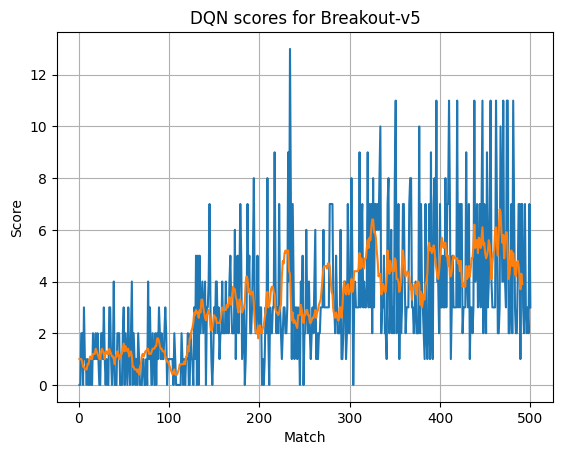